In [6]:
import random

import EoN
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
from scipy.sparse.linalg import eigsh

## Load the UVA contact network

Note that this is a synthetic network and meant to be an approximation of the actual contact patterns.

In [7]:
df = pl.read_csv("../data/uva-network.csv")
print(f"The interaction contexts are {", ".join(df["activity_type"].unique())}")

edges = df[["sourcePID", "targetPID"]].rows()
G = nx.Graph(edges)

The interaction contexts are college, work, home


## Simulating a single measles outbreak

* We used a 2-week average infectious period ($\gamma=1/14$).
* We set $R_0=15$ in line with empirical estimates.

In [8]:
tmin = 0
tmax = 300
N = G.number_of_nodes()
A = nx.adjacency_matrix(G)
l = eigsh(A, k=1)[0].item()

gamma = 1 / 14
reproduction_number = 15

beta = reproduction_number * gamma / l

frac_vaccinated = 0.7
num_infecteds = 2

In [31]:
R0 = set(random.sample(list(G.nodes), int(len(G) * frac_vaccinated)))
I0 = set(random.sample(list(set(G.nodes).difference(R0)), num_infecteds))

t, S, I, R = EoN.fast_SIR(
    G, beta, gamma, initial_infecteds=I0, initial_recovereds=R0, tmin=tmin, tmax=tmax
)

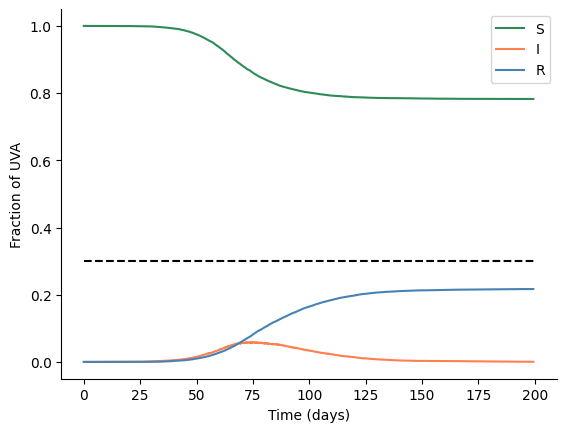

In [32]:
plt.plot(t, S / N, label="S", color="seagreen")
plt.plot(t, I / N, label="I", color="coral")
plt.plot(t, R / N, label="R", color="steelblue")
plt.plot([tmin, tmax], [(1 - frac_vaccinated), (1 - frac_vaccinated)], "k--")
plt.xlabel("Time (days)")
plt.ylabel("Fraction of UVA")
plt.legend()
sns.despine()

## Exploring the effect of vaccination rate on the outbreak size

Here, we explore different rates of vaccination and one vs. two initially infected individuals.

*Just a heads up that each of the simulation cells below takes a few minutes*

In [11]:
num_realizations = 25
fractions_vaccinated = np.linspace(0, 0.95, 20)
tmax = 200
nodes_set = set(G.nodes)
nodes_list = list(G.nodes)

In [12]:
num_infecteds = 1

final_size1 = np.zeros((len(fractions_vaccinated), num_realizations))
for i, f in enumerate(fractions_vaccinated):
    for j in range(num_realizations):
        R0 = set(random.sample(nodes_list, int(len(nodes_list) * f)))
        I0 = set(random.sample(list(nodes_set.difference(R0)), num_infecteds))
        t, S, I, R = EoN.fast_SIR(
            G,
            beta,
            gamma,
            initial_infecteds=I0,
            initial_recovereds=R0,
            tmin=tmin,
            tmax=tmax,
        )
        final_size1[i, j] = R[-1] - R[0]

In [13]:
num_infecteds = 2

final_size2 = np.zeros((len(fractions_vaccinated), num_realizations))
for i, f in enumerate(fractions_vaccinated):
    for j in range(num_realizations):
        R0 = set(random.sample(nodes_list, int(len(nodes_list) * f)))
        I0 = set(random.sample(list(nodes_set.difference(R0)), num_infecteds))
        t, S, I, R = EoN.fast_SIR(
            G,
            beta,
            gamma,
            initial_infecteds=I0,
            initial_recovereds=R0,
            tmin=0,
            tmax=100,
        )
        final_size2[i, j] = R[-1] - R[0]

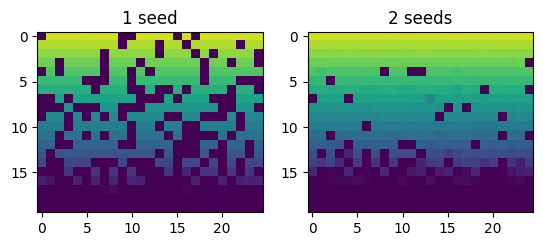

In [14]:
plt.figure()
plt.subplot(121)
plt.title("1 seed")
plt.imshow(final_size1 / N, vmin=0, vmax=1)
plt.subplot(122)
plt.title("2 seeds")
plt.imshow(final_size2 / N, vmin=0, vmax=1)

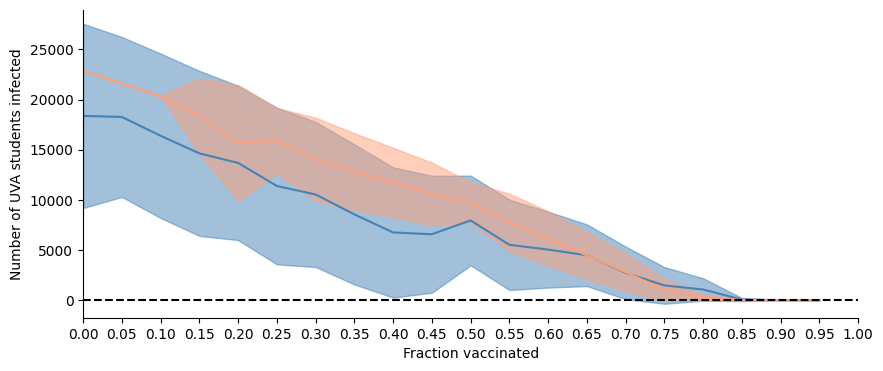

In [15]:
mean1 = final_size1.mean(axis=1)
mean2 = final_size2.mean(axis=1)
std1 = final_size1.std(axis=1)
std2 = final_size2.std(axis=1)
plt.figure(figsize=(10, 4))
plt.plot(fractions_vaccinated, mean1, color="steelblue")
plt.plot(fractions_vaccinated, mean2, color="lightsalmon")
plt.fill_between(
    fractions_vaccinated, mean1 - std1, mean1 + std1, color="steelblue", alpha=0.5
)
plt.fill_between(
    fractions_vaccinated, mean2 - std2, mean2 + std2, color="lightsalmon", alpha=0.5
)
plt.plot([0, 1], [0, 0], "k--")
plt.xlabel("Fraction vaccinated")
plt.ylabel("Number of UVA students infected")
plt.xlim([0, 1])
plt.xticks(np.arange(0, 1.01, 0.05))
sns.despine()

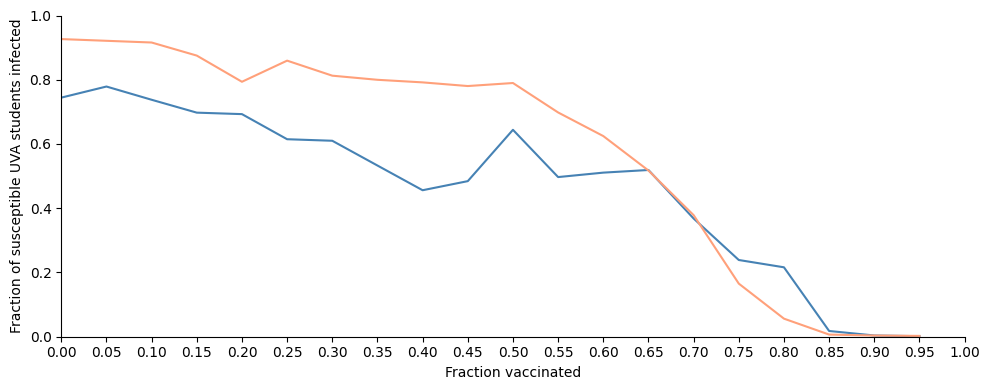

In [16]:
rho1 = (final_size1.mean(axis=1) / N) / (1 - fractions_vaccinated)
rho2 = (final_size2.mean(axis=1) / N) / (1 - fractions_vaccinated)

plt.figure(figsize=(10, 4))
plt.plot(fractions_vaccinated, rho1, color="steelblue")
plt.plot(fractions_vaccinated, rho2, color="lightsalmon")
plt.xlabel("Fraction vaccinated")
plt.ylabel("Fraction of susceptible UVA students infected")
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xticks(np.arange(0, 1.01, 0.05))
sns.despine()
plt.tight_layout()
plt.show()

# Interventions

## Moving to online class
This removes all of the "work" and "college" edges.

In [17]:
edges_intervention1 = df.filter(pl.col("activity_type") == "home")[
    ["sourcePID", "targetPID"]
].rows()
Gintervention1 = nx.Graph(edges_intervention1)

In [18]:
num_infecteds = 1

num_realizations = 25
fractions_vaccinated = np.linspace(0, 0.95, 20)
tmax = 200
nodes_set = set(Gintervention1.nodes)
nodes_list = list(Gintervention1.nodes)

final_size11 = np.zeros((len(fractions_vaccinated), num_realizations))
for i, f in enumerate(fractions_vaccinated):
    for j in range(num_realizations):
        R0 = set(random.sample(nodes_list, int(len(nodes_list) * f)))
        I0 = set(random.sample(list(nodes_set.difference(R0)), num_infecteds))
        t, S, I, R = EoN.fast_SIR(
            Gintervention1,
            beta,
            gamma,
            initial_infecteds=I0,
            initial_recovereds=R0,
            tmin=tmin,
            tmax=tmax,
        )
        final_size11[i, j] = R[-1] - R[0]

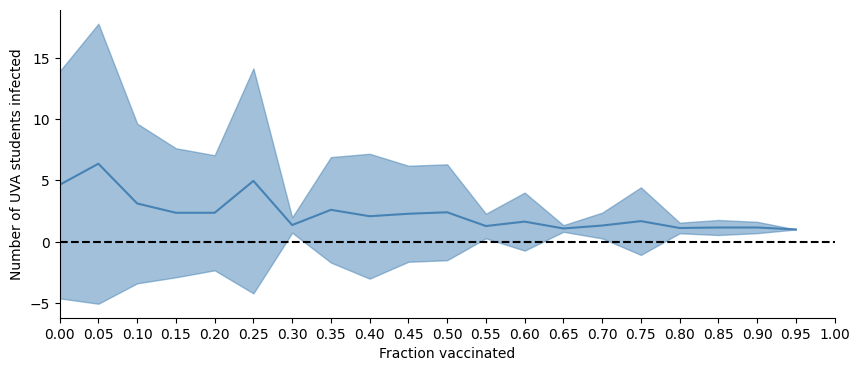

In [19]:
mean1 = final_size11.mean(axis=1)
std1 = final_size11.std(axis=1)
plt.figure(figsize=(10, 4))
plt.plot(fractions_vaccinated, mean1, color="steelblue")
plt.fill_between(
    fractions_vaccinated, mean1 - std1, mean1 + std1, color="steelblue", alpha=0.5
)
plt.plot([0, 1], [0, 0], "k--")
plt.xlabel("Fraction vaccinated")
plt.ylabel("Number of UVA students infected")
plt.xlim([0, 1])
plt.xticks(np.arange(0, 1.01, 0.05))
sns.despine()

## Masking

This reduces the transmission probability by half.

In [20]:
num_infecteds = 1

num_realizations = 25
fractions_vaccinated = np.linspace(0, 0.95, 20)
tmax = 200
nodes_set = set(G.nodes)
nodes_list = list(G.nodes)

mask_performance = 0.5

final_size12 = np.zeros((len(fractions_vaccinated), num_realizations))
for i, f in enumerate(fractions_vaccinated):
    for j in range(num_realizations):
        R0 = set(random.sample(nodes_list, int(len(nodes_list) * f)))
        I0 = set(random.sample(list(nodes_set.difference(R0)), num_infecteds))
        t, S, I, R = EoN.fast_SIR(
            G,
            (1 - mask_performance) * beta,
            gamma,
            initial_infecteds=I0,
            initial_recovereds=R0,
            tmin=tmin,
            tmax=tmax,
        )
        final_size12[i, j] = R[-1] - R[0]

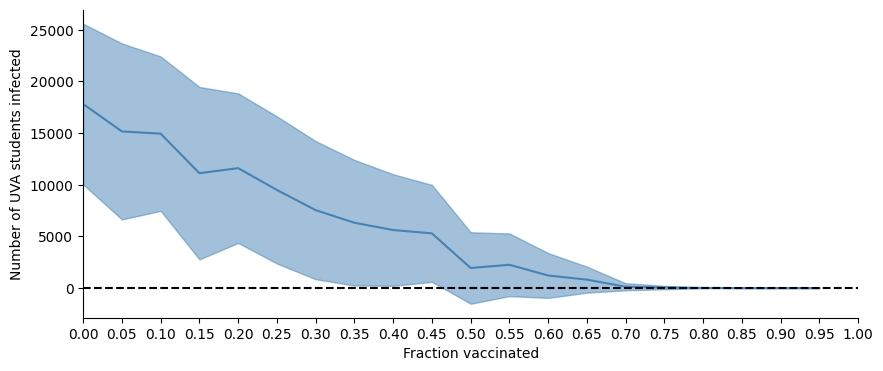

In [21]:
mean1 = final_size12.mean(axis=1)
std1 = final_size12.std(axis=1)
plt.figure(figsize=(10, 4))
plt.plot(fractions_vaccinated, mean1, color="steelblue")
plt.fill_between(
    fractions_vaccinated, mean1 - std1, mean1 + std1, color="steelblue", alpha=0.5
)
plt.plot([0, 1], [0, 0], "k--")
plt.xlabel("Fraction vaccinated")
plt.ylabel("Number of UVA students infected")
plt.xlim([0, 1])
plt.xticks(np.arange(0, 1.01, 0.05))
sns.despine()